In [3]:
import torch
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt
import torch.nn as nn 
from torch.utils.data import DataLoader


In [4]:
import torch.optim as optim

In [5]:
%load_ext autoreload
%autoreload 2

In [8]:
from src import model as ae_model

In [23]:
# Configuración de hardware acelerado
device = (
    "cuda" if torch.cuda.is_available() 
    else "mps" if torch.backends.mps.is_available() 
    else "cpu"
)
print(f"Usando el dispositivo: {device}")

Usando el dispositivo: cuda


In [24]:
## importamos los dataloaders
from src.datadogs import dog_train_loader, dog_test_loader

In [11]:
## parametros para probar entrenamiento autoencoder

params = {
    'in_c': 3,
    # --- ENCODER ---
    'Conv2DParams1': {'out_c': 64, 'kernel_size': 3, 'strides': 1, 'padding': 1, 
                      'activation': 'relu', 'batch_normalization': True, 'dropout_rate': 0.1},
    'Conv2DParams2': {'out_c': 128, 'kernel_size': 3, 'strides': 2, 'padding': 1, 
                      'activation': 'relu', 'batch_normalization': True, 'dropout_rate': 0.1},
    
    # Pass-through debe terminar con 128 canales y stride total de 2 para sumar con Conv2DParams2
    'PassThroughParams1': {'out_c': 64, 'kernel_size': 1, 'strides': 1, 'padding': 0, 
                           'activation': 'relu', 'batch_normalization': True, 'dropout_rate': 0.0},
    'PassThroughParams2': {'out_c': 128, 'kernel_size': 3, 'strides': 2, 'padding': 1, 
                           'activation': 'relu', 'batch_normalization': True, 'dropout_rate': 0.0},
    
    'Conv2DParams3': {'out_c': 256, 'kernel_size': 3, 'strides': 2, 'padding': 1, 
                      'activation': 'relu', 'batch_normalization': True, 'dropout_rate': 0.2},

    # --- DECODER ---
    'Conv2DTransposeParams3': {'out_c': 128, 'kernel_size': 3, 'strides': 2, 'padding': 1, 
                               'activation': 'relu', 'batch_normalization': True, 'dropout_rate': 0.0},
    'Conv2DTransposeParams2': {'out_c': 64, 'kernel_size': 3, 'strides': 2, 'padding': 1, 
                               'activation': 'relu', 'batch_normalization': True, 'dropout_rate': 0.0},
    
    # MixParams recibe d2_out (64) + c1_out (64), mantiene 64 canales
    'MixParams': {'out_c': 64, 'kernel_size': 3, 'strides': 1, 'padding': 1, 
                  'activation': 'relu', 'batch_normalization': True, 'dropout_rate': 0.0},
    
    # Salida final: 3 canales para las 3 clases del dataset
    'Conv2DTransposeParams1': {'out_c': 3, 'kernel_size': 3, 'strides': 1, 'padding': 1, 
                               'activation': None, 'batch_normalization': False, 'dropout_rate': 0.0}
}

In [25]:
model = ae_model.AutoEncoderDown3(params).to(device)

In [26]:
model.load_state_dict(torch.load("ae_pesos_base2.pth"))

<All keys matched successfully>

Loss en el batch de prueba: 0.6957


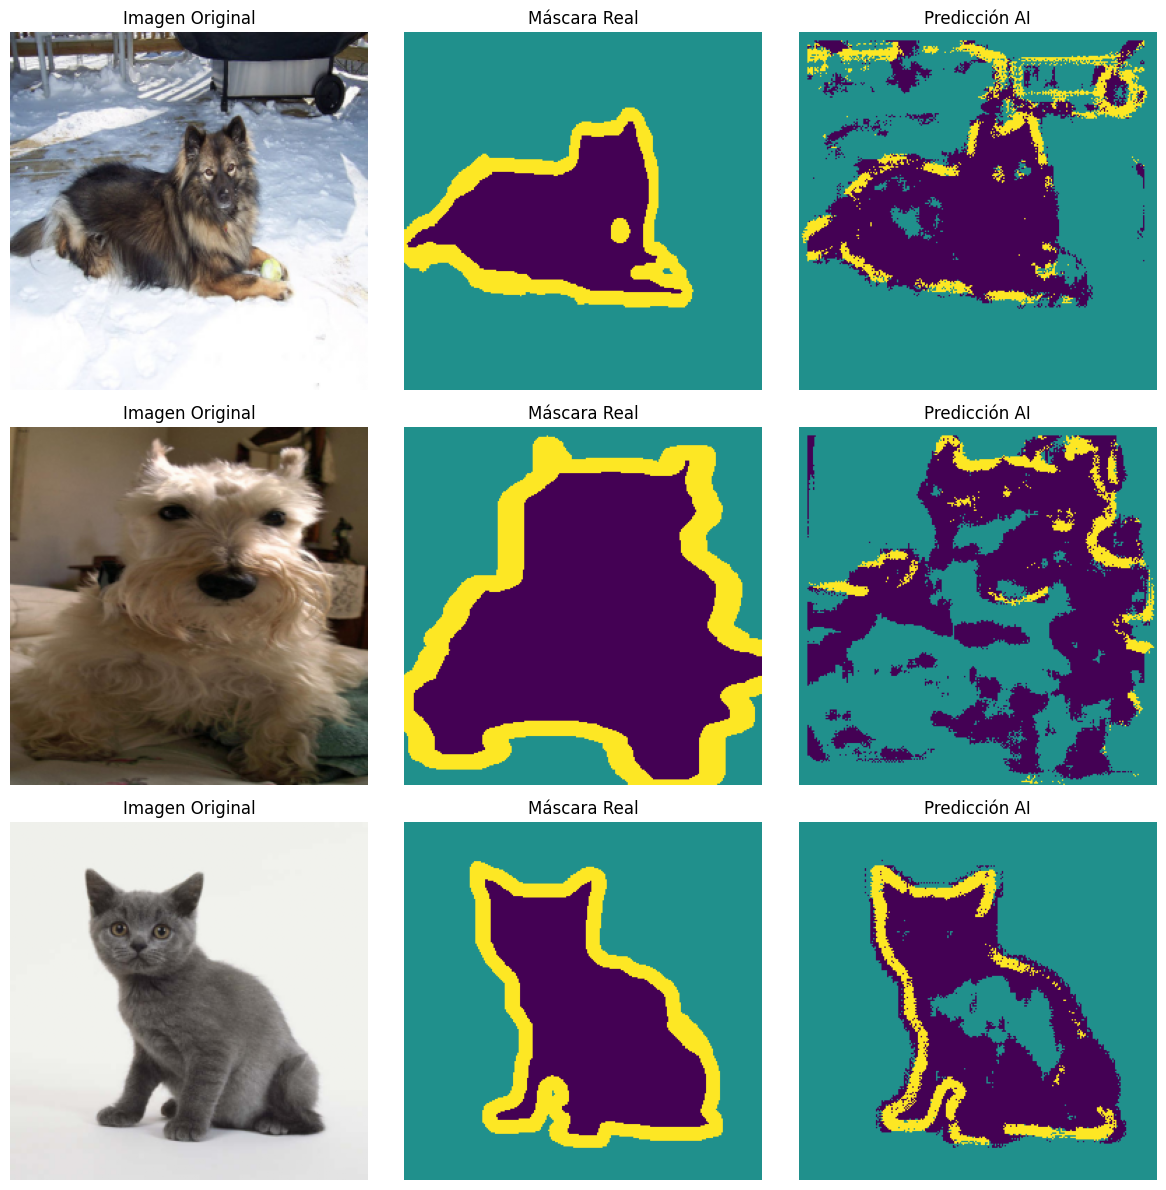

In [28]:
# Ejecutar la prueba
probar_modelo(model, dog_test_loader, device)

In [29]:
## instaciamos el modelo
nca_entero = ae_model.MetaNCASegmenter(ae_params=params, nca_steps=8).to(device)

In [30]:
# Cargar los pesos   
nca_entero.ae.load_state_dict(torch.load("ae_pesos_base2.pth"))
print("Pesos del Autoencoder cargados correctamente.")

Pesos del Autoencoder cargados correctamente.


In [20]:
nca_entero.load_state_dict(torch.load("meta_nca2.pth"))

<All keys matched successfully>

In [41]:
from src.train import train_ae, train_metanca

In [42]:
train_metanca(nca_entero, dog_train_loader, epochs=1, device=device)

 Congelando parámetros del Autoencoder...
 Iniciando loop de prueba preliminar blindado...

✅ Van 10 batches procesados exitosamente.
📊 Loss promedio actual: 0.7647
💧 Leak Factor actual: 0.0921


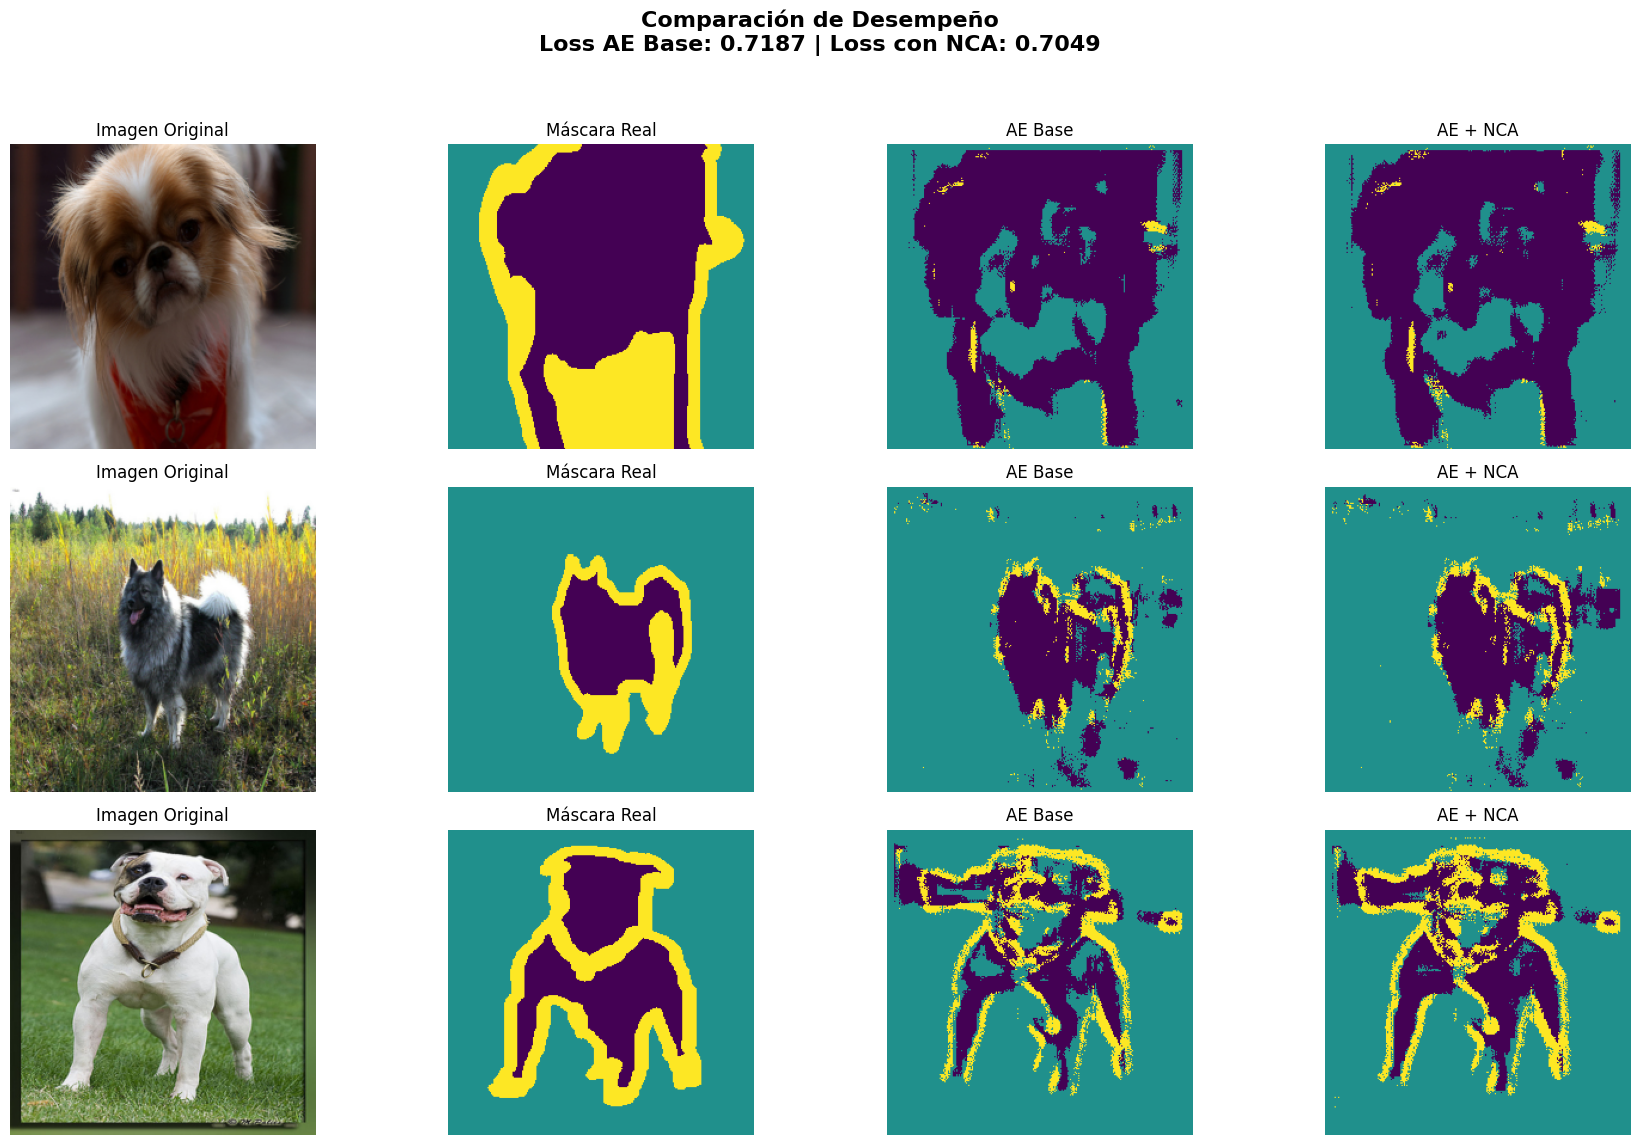

In [46]:
comparar_modelos(nca_entero.ae, nca_entero, dog_test_loader, device, num_images=3)